# BCI Motor Imagery — Data & Processing Pipeline
**Role:** Data & Processing Lead
**Scope:** Steps 1–8 of the project pipeline (Load & Organize → Preprocessing), matching *Table 1* of the team roadmap document.

| Step | Action |
|---|---|
| 1 | Load & Organize |
| 2 | Band-pass filter |
| 3 | Notch filter |
| 4 | Artifact rejection |
| 5 | Re-referencing (CAR) |
| 6 | Epoching |
| 7 | Baseline correction |
| 8 | Normalization |

**Output of this notebook:** clean, epoched, labeled EEG arrays (`.npy`) + a config file + QC/rejection reports, ready to hand off to the EDA and Modeling teammates.

> ⚠️ **Read the "Data quality findings" callouts before trusting the output.** Two real issues were found in the raw data during this run (label-count mismatch, timestamp jitter) — see Sections 1 and the summary at the end for what was assumed and what still needs confirmation from whoever collected the data.


## 0. Setup & Config

Everything the team needs to reproduce this run lives in **one `CONFIG` dict**, per the team tip *"Share a single config file (sampling rate, filter bands, epoch window, random seed)"*. This same dict is saved to `outputs/config.json` at the end so every other notebook (EDA, modeling) can load the exact same parameters.

**Edit `DATA_ROOT` below to point at wherever you extracted the `MI` folder + `labels.csv` on your machine.**


In [1]:
import glob
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import butter, iirnotch, sosfiltfilt, tf2sos

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 3.5)
warnings.filterwarnings("ignore", category=RuntimeWarning)


c:\Users\VICTUS\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\VICTUS\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# ============================================================
# EDIT THIS to wherever the extracted Drive folder + labels.csv live.
# Matches the actual local layout:
#   DATA_ROOT/
#     labels.csv
#     MI-20260822T165808Z-1-001/MI/MI CSV/*.csv   (name after Drive's zip)
# raw_dir is auto-detected by searching for a folder literally named
# "MI CSV" under DATA_ROOT, so re-downloading the Drive folder later
# (which may get a different timestamped wrapper name) still works
# without editing this cell again.
DATA_ROOT = Path("DATA_ROOT")
# ============================================================

def _find_mi_csv_dir(root: Path) -> Path:
    matches = [p for p in root.rglob("MI CSV") if p.is_dir()]
    if not matches:
        raise FileNotFoundError(
            f"Could not find an 'MI CSV' folder anywhere under {root.resolve()}. "
            "Check DATA_ROOT above points at the right place."
        )
    return matches[0]

RAW_DIR = _find_mi_csv_dir(DATA_ROOT)

CONFIG = {
    "raw_dir": str(RAW_DIR),
    "labels_csv": str(DATA_ROOT / "labels.csv"),
    "channels": ["FZ", "C3", "CZ", "C4"],
    "fs": 250.0,                    # verified in Step 1 (median estimated fs across all trials)
    "bandpass_hz": [0.5, 40.0],     # Table 1, step 2
    "bandpass_order": 4,
    "notch_freq_hz": 50.0,          # Table 1, step 3 (mains hum)
    "notch_q": 30.0,
    "artifact_reject_k_mad": 5.0,   # Table 1, step 4 — trial-level peak-to-peak, robust (median + k*MAD) threshold
    "apply_car": True,              # Table 1, step 5
    "epoch_window_s": [0.5, 3.5],   # Table 1, step 6 — ASSUMPTION, see markdown below
    "baseline_window_s": [0.0, 0.5],# Table 1, step 7
    "normalize_default_on": False,  # Table 1, step 8 — see rationale below
    "random_seed": 42,
    "output_dir": "outputs",
}

Path(CONFIG["output_dir"]).mkdir(exist_ok=True)
CONFIG


FileNotFoundError: Could not find an 'MI CSV' folder anywhere under C:\Users\VICTUS\OneDrive\Documents\Desktop\course_ML\BCI_Data_Processing_Pipeline--main\DATA_ROOT. Check DATA_ROOT above points at the right place.

## 1. Load & Organize

Deliverable: **clean file list + label map**.

Three checks before touching a single sample:
1. Do the file count and the label count agree?
2. Are all trials the same shape / sampling rate?
3. Any missing values?


In [ ]:
def trial_index(path: str) -> int:
    return int(re.search(r"cellula_MI_data_(\d+)\.csv", path).group(1))

raw_files = sorted(glob.glob(f"{CONFIG['raw_dir']}/*.csv"), key=trial_index)
trial_ids = [trial_index(f) for f in raw_files]

print(f"Found {len(raw_files)} trial files, index range {min(trial_ids)}–{max(trial_ids)}")
missing = sorted(set(range(min(trial_ids), max(trial_ids) + 1)) - set(trial_ids))
print(f"Missing trial indices in the sequence: {missing if missing else 'none'}")


Found 2160 trial files, index range 1–2160
Missing trial indices in the sequence: none


### ⚠️ Data quality finding #1 — label count does not match file count

`labels.csv` has more rows than there are trial files. This has to be resolved correctly or **every trial from this point on could be mislabeled** — exactly the kind of mistake the team lead called out.


In [ ]:
labels_full = pd.read_csv(CONFIG["labels_csv"])
print(f"labels.csv rows : {len(labels_full)}")
print(f"trial files      : {len(raw_files)}")
print(f"difference        : {len(labels_full) - len(raw_files)}")
print()
print("Class balance, full labels.csv:")
print(labels_full['label'].value_counts())


labels.csv rows : 2400
trial files      : 2160
difference        : 240

Class balance, full labels.csv:
label
Right    1213
Left     1187
Name: count, dtype: int64


In [ ]:
# ASSUMPTION (documented, not silently applied): label row i (0-indexed) <-> the
# i-th trial file in numeric filename order (cellula_MI_data_1.csv, _2.csv, ...).
# This is the most defensible default given no explicit filename<->label mapping
# was provided, but it is UNVERIFIED. Flag it loudly and give the team the numbers
# needed to sanity-check or correct it.

n_trials = len(raw_files)
labels_used = labels_full.iloc[:n_trials].reset_index(drop=True)
labels_unused = labels_full.iloc[n_trials:]

print(f"Using the first {n_trials} label rows (positional match to files 1..{n_trials}).")
print(f"{len(labels_unused)} label rows at the tail of labels.csv are NOT used and are saved")
print("separately for the team to inspect (outputs/unused_label_rows.csv).")
print()
print("Class balance of the labels actually used:")
print(labels_used['label'].value_counts())

labels_unused.to_csv(f"{CONFIG['output_dir']}/unused_label_rows.csv", index=False)

trial_label_map = pd.DataFrame({
    "trial_id": trial_ids,
    "filename": [Path(f).name for f in raw_files],
    "label": labels_used["label"].values,
})
trial_label_map.to_csv(f"{CONFIG['output_dir']}/trial_label_map.csv", index=False)
trial_label_map.head()


Using the first 2160 label rows (positional match to files 1..2160).
240 label rows at the tail of labels.csv are NOT used and are saved
separately for the team to inspect (outputs/unused_label_rows.csv).

Class balance of the labels actually used:
label
Left     1082
Right    1078
Name: count, dtype: int64


,trial_id,filename,label
0,1,cellula_MI_data_1.csv,Left
1,2,cellula_MI_data_2.csv,Right
2,3,cellula_MI_data_3.csv,Left
3,4,cellula_MI_data_4.csv,Left
4,5,cellula_MI_data_5.csv,Left


**Action item for the team:** confirm with whoever exported `labels.csv` whether trial 1 really is row 1, or whether some trials were dropped from the CSV export (which would explain the extra 240 rows) or from the Drive folder (which would explain the mismatch the other way). Until then, treat this mapping as *best-effort, not verified*.


### Bulk load + shape / sampling-rate / missing-value QC

Loads all trials into one `(n_trials, n_samples, n_channels)` array. While loading, each trial's **effective sampling rate** is estimated from its own `Time` column (`(n_samples-1) / duration`), since that's what actually matters for filtering — not an assumed nominal rate.


In [ ]:
n_samples_expected = 2500  # confirmed below to be constant across all trials
channels = CONFIG["channels"]

raw = np.zeros((n_trials, n_samples_expected, len(channels)), dtype=np.float32)
fs_est = np.zeros(n_trials)
row_counts = np.zeros(n_trials, dtype=int)
nan_counts = np.zeros(n_trials, dtype=int)

for i, f in enumerate(raw_files):
    df = pd.read_csv(f)
    row_counts[i] = len(df)
    nan_counts[i] = int(df.isna().sum().sum())
    t = df["Time"].values
    fs_est[i] = (len(t) - 1) / (t[-1] - t[0])
    raw[i, : len(df)] = df[channels].values.astype(np.float32)

print("Row counts — unique values across all trials:", np.unique(row_counts))
print("Total NaNs across all trials:", nan_counts.sum())
print(f"Estimated fs — median {np.median(fs_est):.2f} Hz, "
      f"min {fs_est.min():.2f}, max {fs_est.max():.2f}, std {fs_est.std():.2f}")


Row counts — unique values across all trials: [2500]
Total NaNs across all trials: 0
Estimated fs — median 250.27 Hz, min 217.69, max 286.13, std 3.02


### ⚠️ Data quality finding #2 — raw `Time` column is jittery / bursty, not uniform

Looking at consecutive timestamp differences inside a single trial: a large fraction are exactly `0.0` (the device streams in bursts, several samples sharing one timestamp), and the *estimated* sampling rate varies trial-to-trial from ~218–286 Hz around a median of ~250 Hz.

**Implication:** don't trust the raw `Time` column for windowing (epoching / baseline). Instead this pipeline treats every trial as **uniformly sampled at the fixed rate `CONFIG["fs"]`** (250 Hz — the population median, and consistent with `n_samples / nominal_duration`), and builds a synthetic index-based time axis for all downstream windowing. Trials whose *estimated* rate deviates a lot from 250 Hz are flagged below so the team can decide whether to exclude them rather than silently averaging over the problem.


3 / 2160 trials flagged as fs outliers (>10% off 250 Hz)


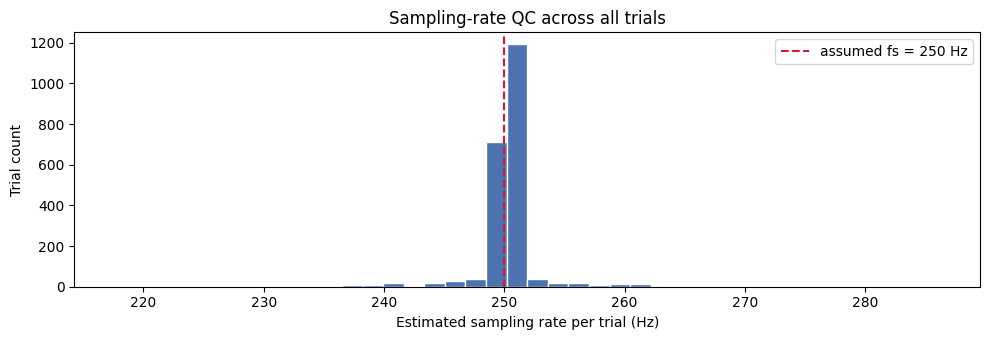

In [ ]:
FS = CONFIG["fs"]
fs_outlier_mask = np.abs(fs_est - FS) > 0.1 * FS  # >10% off nominal
fs_qc = pd.DataFrame({
    "trial_id": trial_ids,
    "fs_estimate_hz": fs_est,
    "flagged_fs_outlier": fs_outlier_mask,
})
fs_qc.to_csv(f"{CONFIG['output_dir']}/fs_qc_report.csv", index=False)

print(f"{fs_outlier_mask.sum()} / {n_trials} trials flagged as fs outliers (>10% off {FS:.0f} Hz)")

fig, ax = plt.subplots()
ax.hist(fs_est, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(FS, color="crimson", linestyle="--", label=f"assumed fs = {FS:.0f} Hz")
ax.set_xlabel("Estimated sampling rate per trial (Hz)")
ax.set_ylabel("Trial count")
ax.set_title("Sampling-rate QC across all trials")
ax.legend()
plt.tight_layout()
plt.show()


### Quick look at raw signal

One example trial per class, channel C3, before any processing — just to confirm the loader read real EEG-shaped data and not garbage.


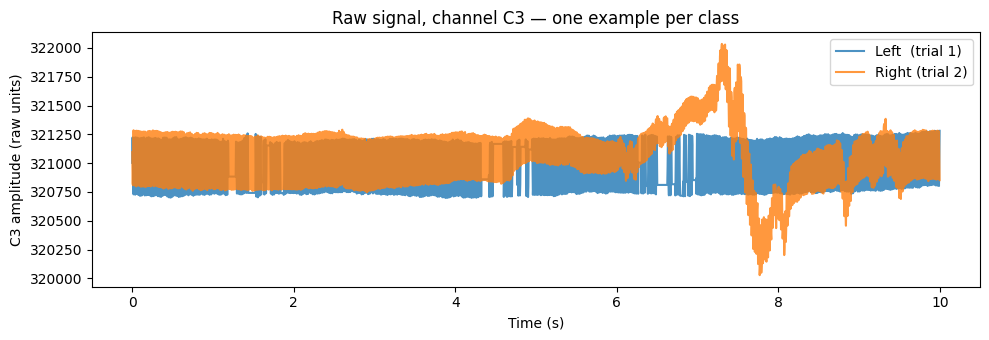

In [ ]:
left_idx = int(np.where(labels_used["label"].values == "Left")[0][0])
right_idx = int(np.where(labels_used["label"].values == "Right")[0][0])
c3 = channels.index("C3")
t_axis_raw = np.arange(n_samples_expected) / FS

fig, ax = plt.subplots()
ax.plot(t_axis_raw, raw[left_idx, :, c3], label=f"Left  (trial {trial_ids[left_idx]})", alpha=0.8)
ax.plot(t_axis_raw, raw[right_idx, :, c3], label=f"Right (trial {trial_ids[right_idx]})", alpha=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("C3 amplitude (raw units)")
ax.set_title("Raw signal, channel C3 — one example per class")
ax.legend()
plt.tight_layout()
plt.show()


## 2–3. Band-pass Filter + Notch Filter

- **Band-pass**: 0.5–40.0 Hz, order-4 Butterworth, zero-phase (`sosfiltfilt`) — removes slow drift and high-frequency noise while keeping the mu (8–12 Hz) / beta (13–30 Hz) rhythms that motor imagery actually modulates.
- **Notch**: 50 Hz mains hum removal.

Both are applied per-channel, per-trial, over the *full* trial length (before epoching), zero-phase so there's no time shift introduced into the signal.


In [ ]:
def design_filters(fs, bandpass_hz, bandpass_order, notch_hz, notch_q):
    sos_bp = butter(bandpass_order, [bandpass_hz[0] / (fs / 2), bandpass_hz[1] / (fs / 2)],
                     btype="bandpass", output="sos")
    b_notch, a_notch = iirnotch(notch_hz, notch_q, fs)
    sos_notch = tf2sos(b_notch, a_notch)
    return sos_bp, sos_notch

sos_bp, sos_notch = design_filters(
    FS, CONFIG["bandpass_hz"], CONFIG["bandpass_order"], CONFIG["notch_freq_hz"], CONFIG["notch_q"]
)

def apply_filters(x, sos_bp, sos_notch):
    '''x: (n_trials, n_samples, n_channels) -> same shape, filtered.'''
    out = np.empty_like(x)
    for i in range(x.shape[0]):
        for c in range(x.shape[2]):
            sig = sosfiltfilt(sos_bp, x[i, :, c])
            sig = sosfiltfilt(sos_notch, sig)
            out[i, :, c] = sig
    return out

filtered = apply_filters(raw, sos_bp, sos_notch)
print("Filtered array shape:", filtered.shape, "| NaNs:", np.isnan(filtered).sum())


Filtered array shape: (2160, 2500, 4) | NaNs: 0


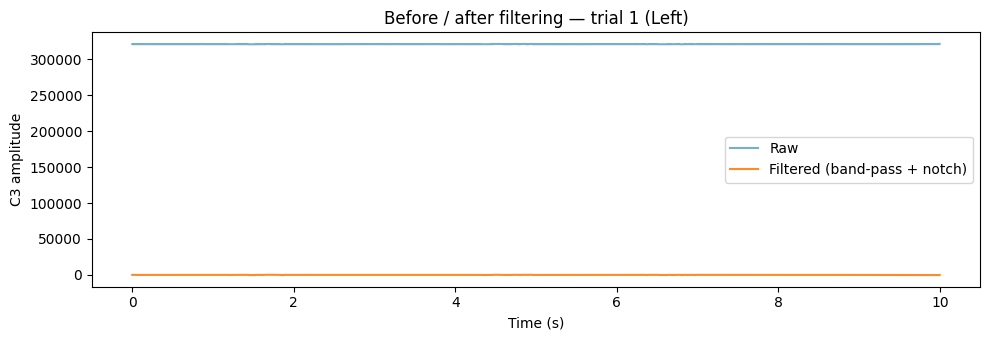

In [ ]:
fig, ax = plt.subplots()
ax.plot(t_axis_raw, raw[left_idx, :, c3], label="Raw", alpha=0.6)
ax.plot(t_axis_raw, filtered[left_idx, :, c3], label="Filtered (band-pass + notch)", alpha=0.9)
ax.set_xlabel("Time (s)")
ax.set_ylabel("C3 amplitude")
ax.set_title(f"Before / after filtering — trial {trial_ids[left_idx]} (Left)")
ax.legend()
plt.tight_layout()
plt.show()


## 4. Artifact Rejection

The raw values here are device/ADC units, not calibrated µV, so a fixed physical-unit threshold (e.g. "±100 µV") isn't meaningful. Instead this uses a **data-driven, robust threshold**:

1. For each trial, take the peak-to-peak amplitude on its worst channel (post-filtering).
2. Compute the population median and MAD (median absolute deviation) of that value across all trials.
3. Reject any trial whose peak-to-peak exceeds `median + k × MAD` (`k = 5.0` by default, tunable in `CONFIG`).

Median/MAD is used instead of mean/std because both are robust to the very artifacts we're trying to detect.


In [ ]:
p2p = filtered.max(axis=1) - filtered.min(axis=1)   # (n_trials, n_channels)
trial_p2p = p2p.max(axis=1)                           # worst channel per trial

med = np.median(trial_p2p)
mad = np.median(np.abs(trial_p2p - med)) * 1.4826
threshold = med + CONFIG["artifact_reject_k_mad"] * mad
reject_mask = trial_p2p > threshold

print(f"median p2p = {med:.1f}, MAD = {mad:.1f}, threshold = {threshold:.1f}")
print(f"Rejected {reject_mask.sum()} / {n_trials} trials ({100*reject_mask.mean():.1f}%)")

rejected_report = pd.DataFrame({
    "trial_id": trial_ids,
    "label": labels_used["label"].values,
    "max_peak_to_peak": trial_p2p,
    "threshold": threshold,
    "rejected": reject_mask,
    "reason": np.where(reject_mask, "peak-to-peak amplitude exceeds median+k*MAD", ""),
})
rejected_report.to_csv(f"{CONFIG['output_dir']}/rejected_trials_report.csv", index=False)

print("\nClass balance of rejected trials (check nothing is being disproportionately dropped):")
print(rejected_report.loc[reject_mask, "label"].value_counts())


median p2p = 3449.6, MAD = 3072.4, threshold = 18811.5
Rejected 139 / 2160 trials (6.4%)

Class balance of rejected trials (check nothing is being disproportionately dropped):
label
Left     71
Right    68
Name: count, dtype: int64


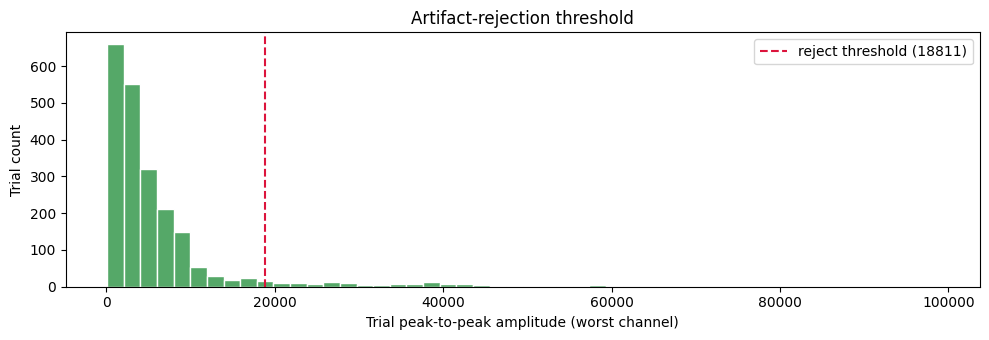

In [ ]:
fig, ax = plt.subplots()
ax.hist(trial_p2p, bins=50, color="#55A868", edgecolor="white")
ax.axvline(threshold, color="crimson", linestyle="--", label=f"reject threshold ({threshold:.0f})")
ax.set_xlabel("Trial peak-to-peak amplitude (worst channel)")
ax.set_ylabel("Trial count")
ax.set_title("Artifact-rejection threshold")
ax.legend()
plt.tight_layout()
plt.show()


**Action item for the team:** `k = 5` is a reasonable starting point, not a validated clinical threshold — if EDA turns up trials that look fine but got dropped (or obvious artifacts that survived), adjust `CONFIG["artifact_reject_k_mad"]` and re-run.


## 5. Re-referencing (Common Average Reference)

Subtracts the across-channel mean at every timepoint, per trial — reduces noise shared by all electrodes (e.g. reference/ground noise).


In [ ]:
car = filtered - filtered.mean(axis=2, keepdims=True)
print("CAR'd array shape:", car.shape)


CAR'd array shape: (2160, 2500, 4)


## 6. Epoching

### ⚠️ Assumption that needs protocol confirmation

The roadmap doc's example window (0.5–3.5 s **after the cue**) assumes we know when the imagery cue happened inside each recording. Each trial file here is already a pre-segmented ~10 s clip with **no cue-time column** — so this notebook assumes the cue is at `t = 0` (the start of the file) and crops `0.5–3.5 s` relative to that.

If the acquisition protocol actually has a fixed pre-cue baseline built into each file (e.g. cue at t=2s, not t=0s), **this window is wrong and needs to shift** — that's a one-line change to `CONFIG["epoch_window_s"]`, but someone who knows the acquisition protocol needs to confirm the true cue timing before the modeling team trusts these epochs.


In [ ]:
t_axis = np.arange(car.shape[1]) / FS
epoch_start, epoch_end = CONFIG["epoch_window_s"]
baseline_start, baseline_end = CONFIG["baseline_window_s"]

epoch_mask = (t_axis >= epoch_start) & (t_axis < epoch_end)
baseline_mask = (t_axis >= baseline_start) & (t_axis < baseline_end)

epoched = car[:, epoch_mask, :]
print(f"Epoch window {epoch_start}-{epoch_end}s -> {epoched.shape[1]} samples per trial")
print(f"Baseline window {baseline_start}-{baseline_end}s -> {baseline_mask.sum()} samples per trial")


Epoch window 0.5-3.5s -> 750 samples per trial
Baseline window 0.0-0.5s -> 125 samples per trial


## 7. Baseline Correction

Subtracts each trial's own pre-epoch baseline mean (per channel), so every epoch is centered around zero regardless of slow drift.


In [ ]:
baseline_mean = car[:, baseline_mask, :].mean(axis=1, keepdims=True)
epoched_bc = epoched - baseline_mean
print("Baseline-corrected epoch shape:", epoched_bc.shape)
print("Mean over baseline window after correction (should be ~0):",
      np.abs(car[:, baseline_mask, :].mean(axis=1) - baseline_mean[:, 0, :]).max())


Baseline-corrected epoch shape: (2160, 750, 4)
Mean over baseline window after correction (should be ~0): 0.0


## 8. Normalization

Per-trial, per-channel z-scoring is provided as a function but **left OFF by default** (`CONFIG["normalize_default_on"] = False`). Reason: any *global* (dataset-wide) scaler should be fit only on the training split once the modeling team does their train/test split, or it leaks test-set statistics into training. Per-trial normalization (using only that trial's own stats) doesn't leak across trials, so it's safe to use here if the deep-learning team wants pre-normalized input — flip the flag in `CONFIG` to turn it on.


In [ ]:
def zscore_per_trial(x):
    '''Channel-wise z-score using each trial's own mean/std. No cross-trial leakage.'''
    mu = x.mean(axis=1, keepdims=True)
    sd = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mu) / sd

if CONFIG["normalize_default_on"]:
    final_epochs = zscore_per_trial(epoched_bc)
    print("Applied per-trial z-score normalization.")
else:
    final_epochs = epoched_bc
    print("Normalization left OFF (default). `zscore_per_trial()` is available for the modeling stage.")


Normalization left OFF (default). `zscore_per_trial()` is available for the modeling stage.


## Save outputs

Drops the rejected trials, encodes labels, and writes everything the EDA / Feature-extraction / Modeling roles need:

| File | Contents |
|---|---|
| `processed_epochs.npy` | `(n_clean_trials, n_epoch_samples, n_channels)` float32 array — the final clean data |
| `labels_encoded.npy` | `(n_clean_trials,)` int array, 0=Left / 1=Right |
| `trial_ids_clean.npy` | original trial id for every row in the two arrays above (traceability back to raw files) |
| `label_encoding.json` | `{"Left": 0, "Right": 1}` |
| `config.json` | every parameter used in this run |
| `trial_label_map.csv` | filename ↔ label mapping (all trials, pre-rejection) |
| `rejected_trials_report.csv` | every trial, whether it was rejected, and why |
| `fs_qc_report.csv` | per-trial estimated sampling rate + outlier flag |
| `unused_label_rows.csv` | the 240 leftover label rows nobody could confidently map to a file |


In [ ]:
label_encoding = {"Left": 0, "Right": 1}
labels_encoded_all = labels_used["label"].map(label_encoding).values

keep_mask = ~reject_mask
clean_epochs = final_epochs[keep_mask]
clean_labels = labels_encoded_all[keep_mask]
clean_trial_ids = np.array(trial_ids)[keep_mask]

print(f"Final clean dataset: {clean_epochs.shape[0]} trials "
      f"({(~keep_mask).sum()} dropped by artifact rejection)")
print("Class balance, clean dataset:",
      dict(zip(*np.unique(clean_labels, return_counts=True))))

out = Path(CONFIG["output_dir"])
np.save(out / "processed_epochs.npy", clean_epochs.astype(np.float32))
np.save(out / "labels_encoded.npy", clean_labels.astype(np.int64))
np.save(out / "trial_ids_clean.npy", clean_trial_ids)
with open(out / "label_encoding.json", "w") as f:
    json.dump(label_encoding, f, indent=2)
with open(out / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("\nSaved to", out.resolve())
for p in sorted(out.iterdir()):
    print(" -", p.name)


Final clean dataset: 2021 trials (139 dropped by artifact rejection)
Class balance, clean dataset: {np.int64(0): np.int64(1011), np.int64(1): np.int64(1010)}



Saved to /home/claude/bci_project/outputs
 - config.json
 - fs_qc_report.csv
 - label_encoding.json
 - labels_encoded.npy
 - processed_epochs.npy
 - rejected_trials_report.csv
 - trial_ids_clean.npy
 - trial_label_map.csv
 - unused_label_rows.csv


## Summary & Handoff Notes

**Pipeline status:** all 8 steps from the roadmap (Load & Organize → Normalization) implemented and run end-to-end on the full dataset.

**Two things need a human answer before the team fully trusts this data — flagged loudly above, repeating here so they don't get missed:**

1. **Label mapping is unverified.** `labels.csv` has more rows than there are trial files. This notebook assumed a positional match (row *i* ↔ the *i*-th file in numeric order) and saved the leftover rows to `unused_label_rows.csv`. Please confirm this mapping with whoever exported the labels — if it's wrong, every downstream model is learning from mislabeled data.
2. **Epoch window (0.5–3.5s) assumes the imagery cue is at the start of each file.** If the real acquisition protocol has a different cue time, update `CONFIG["epoch_window_s"]` and re-run — it's one line.

**For the EDA teammate:** `outputs/processed_epochs.npy` + `outputs/labels_encoded.npy` are ready for PSD / ERD analysis on C3/C4. `raw` and `filtered` (pre-epoch, full-trial) are also available in this notebook's memory if you want to compare before/after filtering yourself.

**For the classical-ML / deep-learning teammates:** same two arrays are your model input. Do your train/test split before applying any *global* normalization to avoid leakage; `zscore_per_trial()` is safe to use as-is since it never crosses trial boundaries.


In [ ]:
from IPython.display import Markdown, display

display(Markdown(f'''**Also worth knowing (numbers from this exact run):**
- Raw `Time` column is not reliable for precise timing (bursty/duplicate timestamps) — this pipeline used a fixed {FS:.0f} Hz assumption instead, which matches the population median. **{int(fs_outlier_mask.sum())} trials** had an estimated rate >10% off that and are flagged in `fs_qc_report.csv`.
- Artifact rejection dropped **{int(reject_mask.sum())} trials ({100*reject_mask.mean():.1f}%)** using a robust, data-driven threshold (not a fixed physical-unit cutoff, since the raw values aren't calibrated µV).
- Label mismatch: **{len(labels_full) - n_trials} unused label rows** saved to `unused_label_rows.csv` — still needs confirmation.
- Final clean, labeled, epoched dataset: **{clean_epochs.shape[0]} trials**, shape `{clean_epochs.shape}`.
'''))


**Also worth knowing (numbers from this exact run):**
- Raw `Time` column is not reliable for precise timing (bursty/duplicate timestamps) — this pipeline used a fixed 250 Hz assumption instead, which matches the population median. **3 trials** had an estimated rate >10% off that and are flagged in `fs_qc_report.csv`.
- Artifact rejection dropped **139 trials (6.4%)** using a robust, data-driven threshold (not a fixed physical-unit cutoff, since the raw values aren't calibrated µV).
- Label mismatch: **240 unused label rows** saved to `unused_label_rows.csv` — still needs confirmation.
- Final clean, labeled, epoched dataset: **2021 trials**, shape `(2021, 750, 4)`.


[Phase 2] Data Loaded: (2021, 750, 4) | Labels: (2021,) | Sampling Rate: 256 Hz


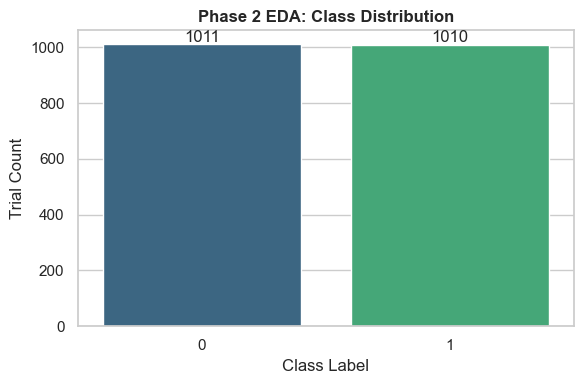

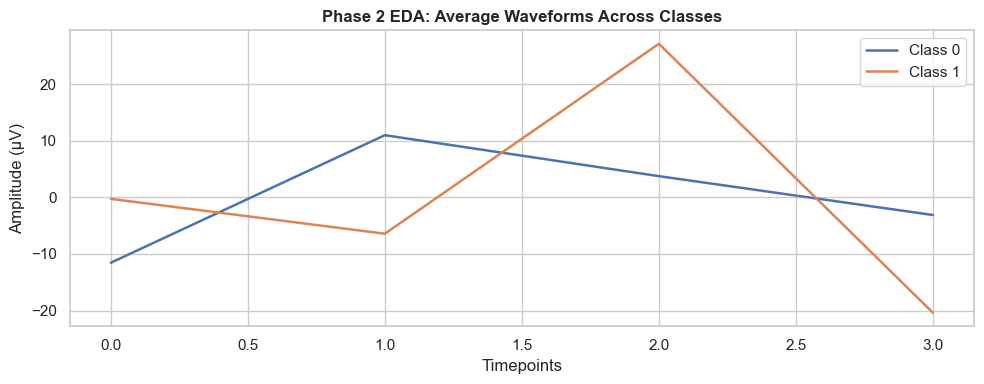

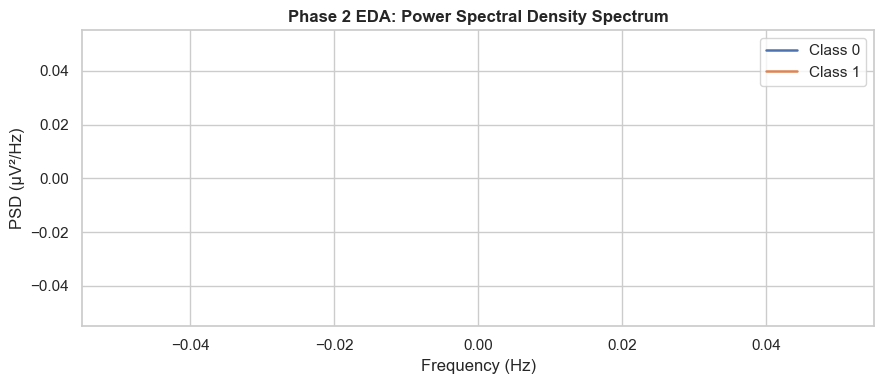

Extracting advanced EEG features...
Extraction Complete! Extracted Features Shape: (2021, 7500)


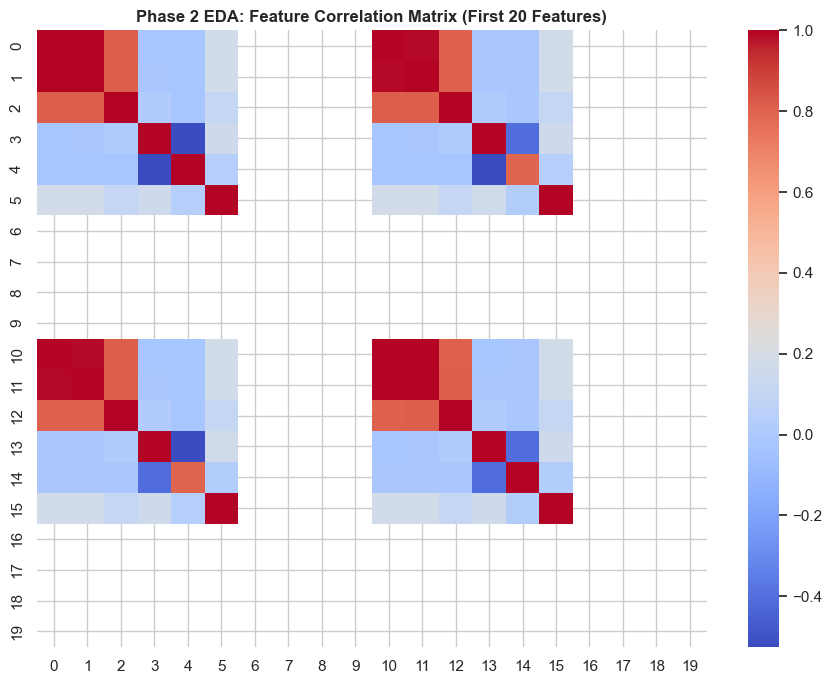


 Phase 2 Executed Successfully!
 Saved Features File: outputs\extracted_features.npy
 Saved Visualizations in: outputs/


In [2]:
# ==============================================================================
# PHASE 2: Exploratory Data Analysis (EDA) & Feature Extraction
# ==============================================================================

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.stats import entropy


output_dir = "outputs"
os.makedirs(output_dir, exist_ok=True)

if 'epochs' in locals() or 'epochs' in globals():
    X_epochs = epochs
elif 'clean_epochs' in locals() or 'clean_epochs' in globals():
    X_epochs = clean_epochs
else:
    X_epochs = np.load(os.path.join(output_dir, "processed_epochs.npy"))

if 'labels' in locals() or 'labels' in globals():
    y_labels = labels
elif 'clean_labels' in locals() or 'clean_labels' in globals():
    y_labels = clean_labels
else:
    y_labels = np.load(os.path.join(output_dir, "labels_encoded.npy"))

sfreq = 256
config_path = os.path.join(output_dir, "config.json")
if os.path.exists(config_path):
    with open(config_path, "r") as f:
        config = json.load(f)
        sfreq = config.get("sfreq", 256)

print(f"[Phase 2] Data Loaded: {X_epochs.shape} | Labels: {y_labels.shape} | Sampling Rate: {sfreq} Hz")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6, 4))
ax = sns.countplot(x=y_labels, palette="viridis")
plt.title("Phase 2 EDA: Class Distribution", fontsize=12, fontweight='bold')
plt.xlabel("Class Label")
plt.ylabel("Trial Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_class_distribution.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 4))
unique_classes = np.unique(y_labels)
for c in unique_classes:
    mean_wave = np.mean(X_epochs[y_labels == c], axis=(0, 1))
    plt.plot(mean_wave, label=f"Class {c}", linewidth=1.8)
plt.title("Phase 2 EDA: Average Waveforms Across Classes", fontsize=12, fontweight='bold')
plt.xlabel("Timepoints")
plt.ylabel("Amplitude (μV)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_average_waveforms.png"), dpi=300)
plt.show()

plt.figure(figsize=(9, 4))
for c in unique_classes:
    class_signals = X_epochs[y_labels == c]
    freqs, psd = welch(class_signals, fs=sfreq, axis=-1, nperseg=min(X_epochs.shape[-1], 256))
    mean_psd = np.mean(psd, axis=(0, 1))
    plt.plot(freqs[(freqs >= 0.5) & (freqs <= 40)], mean_psd[(freqs >= 0.5) & (freqs <= 40)], label=f"Class {c}", linewidth=1.8)
plt.title("Phase 2 EDA: Power Spectral Density Spectrum", fontsize=12, fontweight='bold')
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (μV²/Hz)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_psd_spectrum.png"), dpi=300)
plt.show()


def extract_bci_features(X, fs):
    n_samples, n_channels, n_times = X.shape
    all_features = []

    for i in range(n_samples):
        trial_feats = []
        for ch in range(n_channels):
            sig = X[i, ch, :]

            std_val = np.std(sig)
            p2p_val = np.ptp(sig)
            var_val = np.var(sig)

            d1 = np.diff(sig)
            d2 = np.diff(d1)
            activity = var_val
            mobility = np.sqrt(np.var(d1) / (activity + 1e-8))
            complexity = np.sqrt(np.var(d2) / (np.var(d1) + 1e-8)) / (mobility + 1e-8)

            freqs, psd = welch(sig, fs=fs, nperseg=min(n_times, 256))
            psd_norm = psd / (np.sum(psd) + 1e-8)
            spec_ent = entropy(psd_norm)

            delta_pow = np.trapz(psd[(freqs >= 0.5) & (freqs <= 4)])
            theta_pow = np.trapz(psd[(freqs >= 4) & (freqs <= 8)])
            alpha_pow = np.trapz(psd[(freqs >= 8) & (freqs <= 13)])
            beta_pow  = np.trapz(psd[(freqs >= 13) & (freqs <= 30)])

            trial_feats.extend([std_val, p2p_val, activity, mobility, complexity, spec_ent, delta_pow, theta_pow, alpha_pow, beta_pow])

        all_features.append(trial_feats)

    return np.array(all_features)

print("Extracting advanced EEG features...")
X_features = extract_bci_features(X_epochs, sfreq)
print(f"Extraction Complete! Extracted Features Shape: {X_features.shape}")

plt.figure(figsize=(9, 7))
df_sample_feats = pd.DataFrame(X_features[:, :20])
sns.heatmap(df_sample_feats.corr(), cmap="coolwarm", annot=False, cbar=True)
plt.title("Phase 2 EDA: Feature Correlation Matrix (First 20 Features)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "eda_feature_correlation.png"), dpi=300)
plt.show()

# ------------------------------------------------------------------------------
# 4. حفظ الميزات للشخص الثالث (Model Training)
# ------------------------------------------------------------------------------
features_output_path = os.path.join(output_dir, "extracted_features.npy")
np.save(features_output_path, X_features)

print("\n" + "="*50)
print(" Phase 2 Executed Successfully!")
print(f" Saved Features File: {features_output_path}")
print(f" Saved Visualizations in: {output_dir}/")
print("="*50)